In [1]:
import anndata as ad
import networkx as nx
import scanpy as sc
import scglue
from matplotlib import rcParams
scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

/environment/miniconda3/envs/scglue/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/environment/miniconda3/envs/scglue/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
rna = ad.read_h5ad("adata_RNA.h5ad")
rna.var_names_make_unique()

/environment/miniconda3/envs/scglue/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
rna.var.index.name='genes'

In [4]:
del rna.var['gene_ids']
del rna.var['feature_types']
del rna.var['genome']

In [5]:
atac = ad.read_h5ad("adata_Peak.h5ad")
atac.var_names_make_unique()

In [6]:
new_varnames = []
for p in atac.var_names:
    parts = p.split('.')
    # chromosome 名称可能包含一个或多个小数点（如 GL456216.1）
    chrom = ".".join(parts[:-2])
    start = parts[-2]
    end = parts[-1]
    new_varnames.append(f"{chrom}:{start}-{end}")
atac.var_names = new_varnames

In [7]:
rna.layers["counts"] = rna.X.copy()
sc.pp.filter_genes(rna, min_cells=10)
sc.pp.highly_variable_genes(rna, n_top_genes=3000, flavor="seurat_v3")

In [10]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.tl.pca(rna, n_comps=100, svd_solver="auto")

/environment/miniconda3/envs/scglue/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


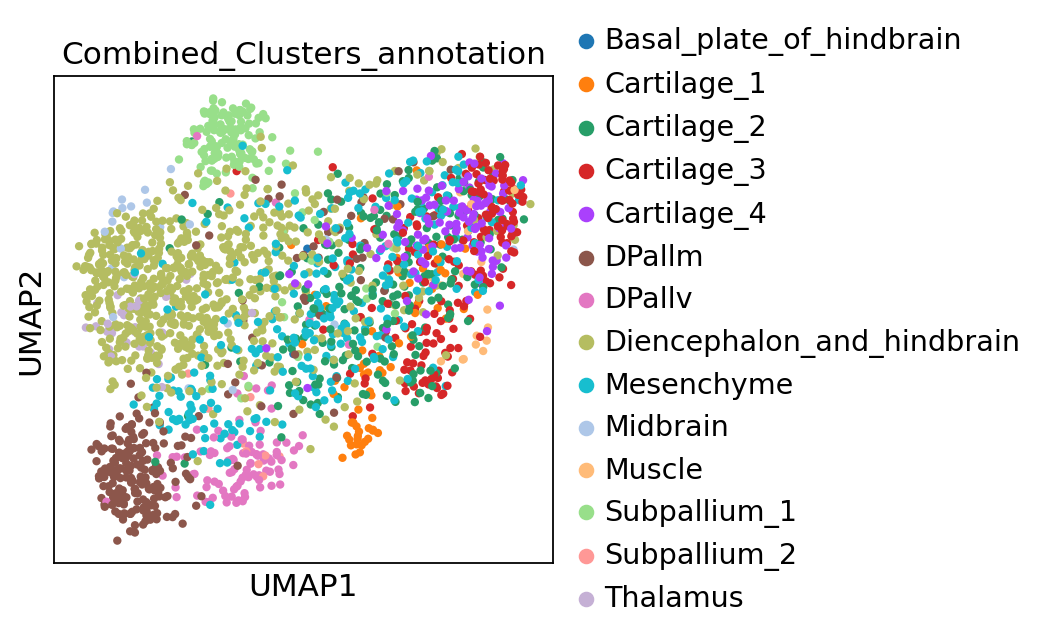

In [11]:
sc.pp.neighbors(rna, metric="cosine")
sc.tl.umap(rna)
sc.pl.umap(rna, color="Combined_Clusters_annotation")

In [12]:
scglue.data.lsi(atac, n_components=100, n_iter=15)

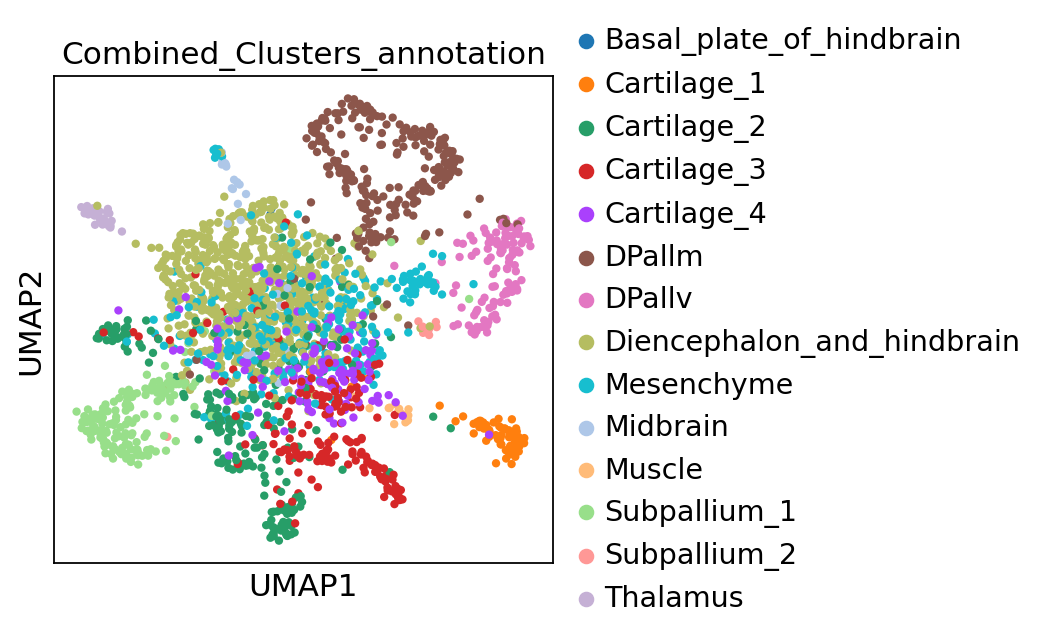

In [13]:
sc.pp.neighbors(atac, use_rep="X_lsi", metric="cosine")
sc.tl.umap(atac)
sc.pl.umap(atac, color="Combined_Clusters_annotation")

In [14]:
scglue.data.get_gene_annotation(
    rna, gtf="gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz",
    gtf_by="gene_name"
)
rna.var.loc[:, ["chrom", "chromStart", "chromEnd"]].head()

,chrom,chromStart,chromEnd
genes,,,
Xkr4,chr1,3205900.0,3671498.0
Gm1992,chr1,3466586.0,3513553.0
Gm19938,chr1,3647308.0,3658904.0
Gm37381,chr1,3905738.0,3986215.0
Rp1,chr1,3999556.0,4409241.0


In [15]:
rna.var

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mean,std,chrom,chromStart,...,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,gene_id,gene_type,mgi_id,havana_gene,tag
genes,,,,,,,,,,,,,,,,,,,,,
Xkr4,1419,False,NaN,1.522311,2.618041,0.977773,0.675789,0.558691,chr1,3205900.0,...,.,.,.,.,.,ENSMUSG00000051951.5,protein_coding,MGI:3528744,OTTMUSG00000026353.2,NaN
Gm1992,72,False,NaN,0.034758,0.035445,1.000773,0.021575,0.127308,chr1,3466586.0,...,.,.,.,.,.,ENSMUSG00000089699.1,antisense,MGI:3780162,OTTMUSG00000026352.1,NaN
Gm19938,104,False,NaN,0.050258,0.050574,0.981246,0.026800,0.127694,chr1,3647308.0,...,.,.,.,.,.,ENSMUSG00000102331.1,sense_intronic,MGI:5012123,OTTMUSG00000049924.1,NaN
Gm37381,81,False,NaN,0.038046,0.036616,0.942908,0.024163,0.133646,chr1,3905738.0,...,.,.,.,.,.,ENSMUSG00000102343.1,lincRNA,MGI:5610609,OTTMUSG00000049934.1,NaN
Rp1,326,False,NaN,0.175200,0.194385,1.032134,0.100130,0.262206,chr1,3999556.0,...,.,.,.,.,.,ENSMUSG00000025900.13,protein_coding,MGI:1341105,OTTMUSG00000049985.3,overlapping_locus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tmlhe,312,False,NaN,0.166275,0.183806,1.032140,0.099596,0.266841,GL456233.1,159646.0,...,.,.,.,.,.,ENSMUSG00000079834.2,protein_coding,MGI:2180203,NaN,NaN
Vmn2r122,12,True,344.0,0.006106,0.007012,1.145125,0.003469,0.050579,JH584292.1,3535.0,...,.,.,.,.,.,ENSMUSG00000096730.7,protein_coding,MGI:1316661,NaN,NaN
4933409K07Rik,66,False,NaN,0.031470,0.031434,0.981932,0.018010,0.105652,JH584293.1,140955.0,...,.,.,.,.,.,ENSMUSG00000095552.1,protein_coding,MGI:1918429,NaN,NaN


In [16]:
rna = rna[:, rna.var["mgi_id"].notna()].copy()

In [17]:
rna.var

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mean,std,chrom,chromStart,...,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,gene_id,gene_type,mgi_id,havana_gene,tag
genes,,,,,,,,,,,,,,,,,,,,,
Xkr4,1419,False,NaN,1.522311,2.618041,0.977773,0.675789,0.558691,chr1,3205900.0,...,.,.,.,.,.,ENSMUSG00000051951.5,protein_coding,MGI:3528744,OTTMUSG00000026353.2,NaN
Gm1992,72,False,NaN,0.034758,0.035445,1.000773,0.021575,0.127308,chr1,3466586.0,...,.,.,.,.,.,ENSMUSG00000089699.1,antisense,MGI:3780162,OTTMUSG00000026352.1,NaN
Gm19938,104,False,NaN,0.050258,0.050574,0.981246,0.026800,0.127694,chr1,3647308.0,...,.,.,.,.,.,ENSMUSG00000102331.1,sense_intronic,MGI:5012123,OTTMUSG00000049924.1,NaN
Gm37381,81,False,NaN,0.038046,0.036616,0.942908,0.024163,0.133646,chr1,3905738.0,...,.,.,.,.,.,ENSMUSG00000102343.1,lincRNA,MGI:5610609,OTTMUSG00000049934.1,NaN
Rp1,326,False,NaN,0.175200,0.194385,1.032134,0.100130,0.262206,chr1,3999556.0,...,.,.,.,.,.,ENSMUSG00000025900.13,protein_coding,MGI:1341105,OTTMUSG00000049985.3,overlapping_locus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Csprs,67,False,NaN,0.031940,0.031874,0.980778,0.018880,0.113715,GL456221.1,111571.0,...,.,.,.,.,.,ENSMUSG00000062783.2,protein_coding,MGI:1891441,NaN,NaN
Vamp7,64,True,2900.0,0.031470,0.033314,1.040650,0.018747,0.117191,GL456233.1,10737.0,...,.,.,.,.,.,ENSMUSG00000051412.6,protein_coding,MGI:1096399,NaN,NaN
Tmlhe,312,False,NaN,0.166275,0.183806,1.032140,0.099596,0.266841,GL456233.1,159646.0,...,.,.,.,.,.,ENSMUSG00000079834.2,protein_coding,MGI:2180203,NaN,NaN


In [18]:
atac.var

""
chr1:3094539-3095481
chr1:3119728-3120654
chr1:3123209-3124083
chr1:3147310-3148326
chr1:3149755-3150616
...
GL456216.1:34737-35623
GL456216.1:48790-49701
GL456216.1:54146-55035
JH584292.1:12569-13507


In [19]:
split = atac.var_names.str.split(r"[:-]")
atac.var["chrom"] = split.map(lambda x: x[0])
atac.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atac.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)
atac.var.head()

,chrom,chromStart,chromEnd
chr1:3094539-3095481,chr1,3094539,3095481
chr1:3119728-3120654,chr1,3119728,3120654
chr1:3123209-3124083,chr1,3123209,3124083
chr1:3147310-3148326,chr1,3147310,3148326
chr1:3149755-3150616,chr1,3149755,3150616


In [20]:
guidance = scglue.genomics.rna_anchored_guidance_graph(rna, atac)
guidance

window_graph: 100%|██████████| 20595/20595 [00:01<00:00, 11206.99it/s]


In [21]:
scglue.graph.check_graph(guidance, [rna, atac])

[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!


In [22]:
rna.write("MISAR-rna-pp.h5ad", compression="gzip")
atac.write("MISAR-atac-pp.h5ad", compression="gzip")
nx.write_graphml(guidance, "MISAR-guidance.graphml.gz")